# Lab type: review
# Course: ML201 — Applied Machine Learning
# Lesson: Gradient Boosting: XGBoost, LightGBM, and CatBoost
# Task: The code below is correct and working. Read each section, run it, then answer the judgment questions in the markdown cells below each block.

In [3]:
!pip install xgboost lightgbm catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

np.random.seed(42)
n = 3000

tenure_months = np.random.exponential(30, n).clip(1, 120).astype(int)
performance_score = np.random.uniform(1, 5, n).round(1)
salary = np.random.normal(75000, 25000, n).clip(30000, 200000)
num_projects = np.random.randint(1, 10, n)
dept_raw = np.random.choice(['engineering', 'sales', 'marketing', 'hr'], n,
                             p=[0.35, 0.30, 0.20, 0.15])
contract_type_raw = np.random.choice(['permanent', 'contract'], n, p=[0.7, 0.3])

log_odds = (
    -2.5
    - 0.02 * tenure_months
    - 0.3 * performance_score
    - 0.000005 * salary
    + 0.1 * num_projects
    + (contract_type_raw == 'contract').astype(float) * 0.8
)
prob_churn = 1 / (1 + np.exp(-log_odds))
churned = (np.random.rand(n) < prob_churn).astype(int)

# Encode categoricals for XGBoost / LightGBM
le_dept = LabelEncoder()
le_contract = LabelEncoder()
dept_enc = le_dept.fit_transform(dept_raw)
contract_enc = le_contract.fit_transform(contract_type_raw)

df_enc = pd.DataFrame({
    'tenure_months': tenure_months,
    'performance_score': performance_score,
    'salary': salary,
    'num_projects': num_projects,
    'dept': dept_enc,
    'contract_type': contract_enc
})
y = pd.Series(churned, name='churned')

# Raw string categoricals for CatBoost
df_cat = pd.DataFrame({
    'tenure_months': tenure_months,
    'performance_score': performance_score,
    'salary': salary,
    'num_projects': num_projects,
    'dept': dept_raw,
    'contract_type': contract_type_raw
})

# Encoded splits (XGBoost / LightGBM)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df_enc, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# Categorical splits (CatBoost)
X_train_full_cat, X_test_cat, y_train_full_cat, y_test_cat = train_test_split(
    df_cat, y, test_size=0.2, random_state=42, stratify=y
)
X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(
    X_train_full_cat, y_train_full_cat, test_size=0.2, random_state=42, stratify=y_train_full_cat
)

print('Split sizes (encoded):')
print(f'  X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')
print(f'Class balance (full dataset):\n{y.value_counts(normalize=True).round(3)}')

Split sizes (encoded):
  X_train: (1920, 6), X_val: (480, 6), X_test: (600, 6)
Class balance (full dataset):
churned
0    0.967
1    0.033
Name: proportion, dtype: float64


## Part 1: XGBoost with Early Stopping

In [5]:
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_best_iter = xgb_model.best_iteration
xgb_test_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

print(f'XGBoost best_iteration : {xgb_best_iter}')
print(f'XGBoost test AUC       : {xgb_test_auc:.4f}')

XGBoost best_iteration : 28
XGBoost test AUC       : 0.6571


**Question 1:** The `eval_set` uses `X_val` (carved from `X_train_full`), not `X_test`. What goes wrong if you pass `eval_set=[(X_test, y_test)]` for early stopping? Why does this make the final test AUC optimistic?

*(Write your answer here.)*

**Question 2:** `early_stopping_rounds=30` stops training when validation AUC has not improved for 30 consecutive rounds. If you set this too low (e.g., 5 rounds), what failure mode occurs? If too high (e.g., 500 rounds)?

*(Write your answer here.)*

## Part 2: LightGBM — Leaf-wise Growth

In [6]:
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(0)]
)

lgbm_best_iter = lgbm_model.best_iteration_
lgbm_test_auc = roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:, 1])

print(f'LightGBM best_iteration_: {lgbm_best_iter}')
print(f'LightGBM test AUC       : {lgbm_test_auc:.4f}')

[LightGBM] [Info] Number of positive: 63, number of negative: 1857
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032813 -> initscore=-3.383583
[LightGBM] [Info] Start training from score -3.383583
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[5]	valid_0's binary_logloss: 0.145457
LightGBM best_iteration_: 5
LightGBM test AUC       : 0.6187


**Question 3:** LightGBM uses leaf-wise tree growth while XGBoost uses level-wise. What does this mean in practice for small datasets (fewer than 500 rows)? Which is more likely to overfit and why?

*(Write your answer here.)*

**Question 4:** `num_leaves=31` in LightGBM roughly corresponds to a `max_depth` of 5 in a balanced binary tree (2^5 = 32 leaves). If you increase `num_leaves` to 127 but keep `learning_rate` the same, what happens to the bias-variance tradeoff? What complementary hyperparameter should you also adjust?

*(Write your answer here.)*

## Part 3: CatBoost — Native Categorical Support

In [7]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    random_seed=42,
    verbose=0
)
catboost_model.fit(
    X_train_cat, y_train_cat,
    cat_features=['dept', 'contract_type'],
    eval_set=(X_val_cat, y_val_cat),
    early_stopping_rounds=30
)

catboost_best_iter = catboost_model.best_iteration_
catboost_test_auc = roc_auc_score(y_test_cat, catboost_model.predict_proba(X_test_cat)[:, 1])

print(f'CatBoost best_iteration_: {catboost_best_iter}')
print(f'CatBoost test AUC       : {catboost_test_auc:.4f}')

CatBoost best_iteration_: 50
CatBoost test AUC       : 0.6832


**Question 5:** CatBoost handles `dept` and `contract_type` without one-hot or label encoding. What is the risk of using naive mean target encoding for categorical features outside a proper cross-validation pipeline? This is the problem CatBoost's ordered target statistics are designed to solve — describe it in concrete terms.

*(Write your answer here.)*

**Question 6:** You have a dataset with five high-cardinality categorical columns (`city`, `product_sku`, `user_segment`, etc.), each with 200+ unique values. Of XGBoost, LightGBM, and CatBoost, which would you choose and why?

*(Write your answer here.)*

## Part 4: Comparison


=== Model Comparison ===
 Library  Best Iteration  Test AUC
 XGBoost              28  0.657069
LightGBM               5  0.618707
CatBoost              50  0.683190


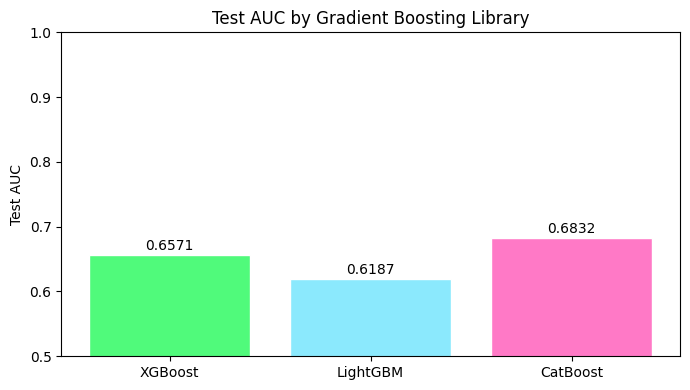

In [8]:
results = pd.DataFrame([
    {'Library': 'XGBoost',   'Best Iteration': xgb_best_iter,      'Test AUC': xgb_test_auc},
    {'Library': 'LightGBM',  'Best Iteration': lgbm_best_iter,     'Test AUC': lgbm_test_auc},
    {'Library': 'CatBoost',  'Best Iteration': catboost_best_iter, 'Test AUC': catboost_test_auc},
])

print('\n=== Model Comparison ===')
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#50fa7b', '#8be9fd', '#ff79c6']
bars = ax.bar(results['Library'], results['Test AUC'], color=colors, edgecolor='white')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Test AUC')
ax.set_title('Test AUC by Gradient Boosting Library')
for bar, val in zip(bars, results['Test AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Question 7:** All three libraries achieved similar AUC on this dataset. What practical factors would still lead you to choose one over the others in a real production project? Name at least two factors and explain the tradeoff each one represents.

*(Write your answer here.)*

## Summary

Check your understanding with these final questions. Each should be answerable in one sentence.

1. Why does using the held-out test set as the early stopping validation set produce an optimistic test AUC, and what is the correct remedy?

2. In one sentence, explain why LightGBM's leaf-wise growth makes it more prone to overfitting on small datasets than XGBoost's level-wise growth.

3. You have a production dataset where new categories appear in live scoring that were not seen during training. Which library's native categorical handling degrades most gracefully in this situation, and why?